<a href="https://colab.research.google.com/github/Abubakarshaikh98/practics_project/blob/main/ML/01_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("calories-checkpoint.csv")
df.head()

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0


In [ ]:
df = df.dropna(axis=0)

In [ ]:
y = df.iloc[:,-1]

<Axes: >

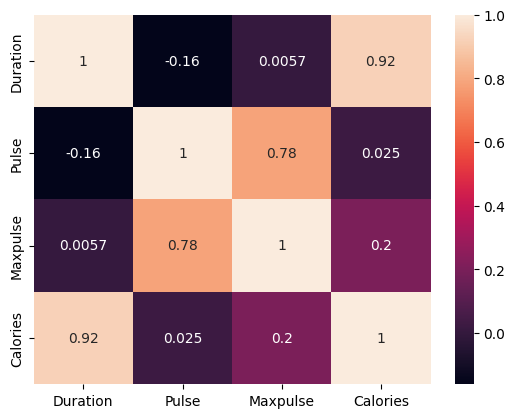

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
x = df["Duration"]

In [ ]:
x = pd.DataFrame(np.array(x).reshape(-1,1))

In [ ]:
y

,Calories
0,409.1
1,479.0
2,340.0
3,282.4
4,406.0
...,...
164,290.8
165,300.0
166,310.2
167,320.4


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=42)

In [ ]:
LR = LinearRegression()

In [ ]:
LR.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = LR.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("RMSE",root_mean_squared_error(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))

MAE 69.14068096685769
RMSE 90.80502867562937
R2 Score 0.7471444773251994


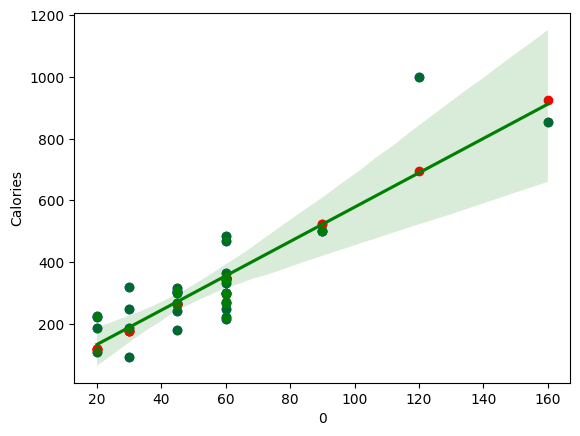

In [ ]:
plt.scatter(x_test,y_test, c="blue")
plt.scatter(x_test,y_pred, c="red")
sns.regplot(x=x_test,y=y_test, color="green")
plt.show()

In [ ]:
LR.predict([[250]])

array([1444.07563899])

**New Dataset**

In [ ]:
cellDF = pd.read_csv("Cellphone.csv")
cellDF.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [ ]:
cellDF.drop("Product_id",axis=1,inplace=True)

In [ ]:
x = cellDF.iloc[:,1:]
y = cellDF.iloc[:,0]

In [ ]:
x.head()

,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [ ]:
c_x_train,c_x_test,c_y_train,c_y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
c_LR = LinearRegression()

In [ ]:
c_LR.fit(c_x_train,c_y_train)

LinearRegression()

In [ ]:
c_pred_train = c_LR.predict(c_x_train)
c_pred_test = c_LR.predict(c_x_test)

In [ ]:
print("Train R2",r2_score(c_y_train,c_pred_train))
print("Test R2",r2_score(c_y_test,c_pred_test))

Train R2 0.9516006085915756
Test R2 0.9614025134850815


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
c_rr = Ridge()


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param ={
    "alpha":[1,2,3,4,5,6,7,8,9,10,20],
}
c_Grid = GridSearchCV(estimator=c_rr,param_grid=param,scoring="r2")

In [ ]:
c_Grid.fit(c_x_train,c_y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20]},
             scoring='r2')

In [ ]:
c_Grid.best_params_

{'alpha': 8}

In [ ]:
c_Grid.best_score_

np.float64(0.928708935837428)